<>:49: SyntaxWarning: invalid escape sequence '\|'
<>:49: SyntaxWarning: invalid escape sequence '\|'
/var/folders/vl/bhxpqkt92cl08282nvzdf8s00000gn/T/ipykernel_51030/1388444319.py:49: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|r_m\|_2 = \|b - A x_m\|_2$')


Iter 5: ||r|| = 1.96e-01
Iter 10: ||r|| = 6.36e-03
Iter 15: ||r|| = 2.44e-04
Iter 20: ||r|| = 3.49e-06
Iter 25: ||r|| = 8.94e-08
Iter 30: ||r|| = 8.80e-10


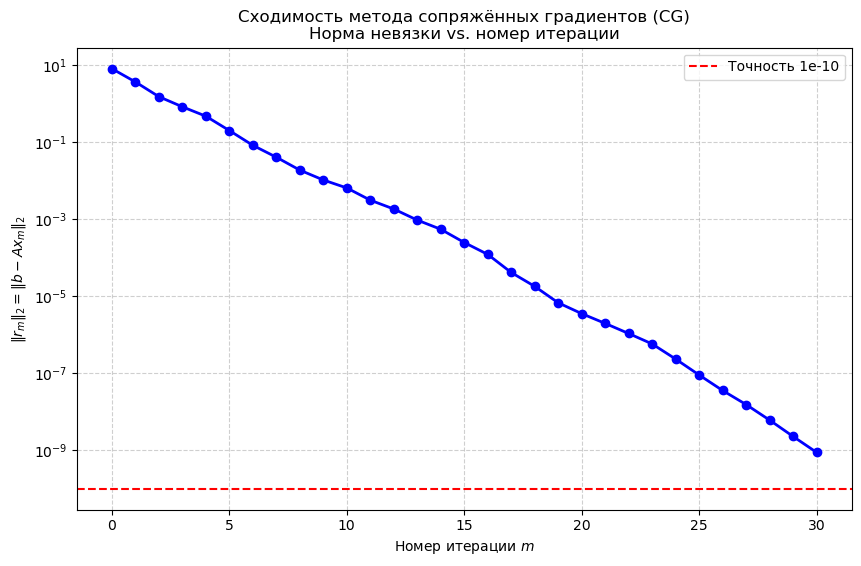


Истинное решение найдено за 30 итераций.
Последняя невязка: 8.80e-10


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Генерируем случайную симметричную положительно определённую матрицу A
np.random.seed(42)
n = 50  # размерность
Q, _ = np.linalg.qr(np.random.randn(n, n))  # ортогональная матрица
eigvals = np.linspace(1, 10, n)  # собственные значения от 1 до 10
A = Q @ np.diag(eigvals) @ Q.T  # A = QΛQ^T

# Вектор правой части
b = np.random.randn(n)

# Начальное приближение
x0 = np.zeros(n)
r0 = b - A @ x0

# Реальное решение (для сравнения)
x_true = np.linalg.solve(A, b)

# Инициализация для CG
x = x0.copy()
r = r0.copy()
p = r.copy()
residual_norms = [np.linalg.norm(r)]

# Максимальное число итераций
max_iter = min(n, 30)  # ограничим для наглядности

for k in range(max_iter):
    Ap = A @ p
    alpha = np.dot(r, r) / np.dot(p, Ap)
    x = x + alpha * p
    r_new = r - alpha * Ap
    beta = np.dot(r_new, r_new) / np.dot(r, r)
    p = r_new + beta * p
    r = r_new
    residual_norms.append(np.linalg.norm(r))

    # Для наглядности — выводим каждые 5 итераций
    if (k+1) % 5 == 0 or k == max_iter-1:
        print(f"Iter {k+1}: ||r|| = {residual_norms[-1]:.2e}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.semilogy(range(len(residual_norms)), residual_norms, 'bo-', linewidth=2, markersize=6)
plt.title('Сходимость метода сопряжённых градиентов (CG)\nНорма невязки vs. номер итерации')
plt.xlabel('Номер итерации $m$')
plt.ylabel('$\|r_m\|_2 = \|b - A x_m\|_2$')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.axhline(y=1e-10, color='red', linestyle='--', label='Точность 1e-10')
plt.legend()
plt.show()

print(f"\nИстинное решение найдено за {len(residual_norms)-1} итераций.")
print(f"Последняя невязка: {residual_norms[-1]:.2e}")

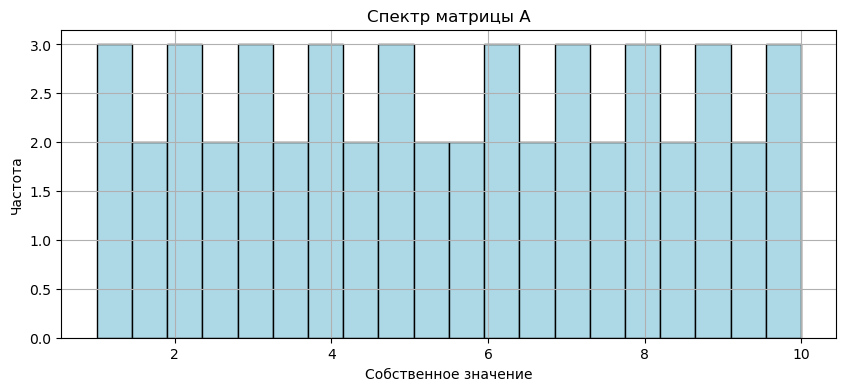

In [4]:
# Добавим после генерации A:
eigvals_A = np.linalg.eigvalsh(A)  # собственные значения (для симметричной матрицы)

plt.figure(figsize=(10, 4))
plt.hist(eigvals_A, bins=20, color='lightblue', edgecolor='black')
plt.title('Спектр матрицы A')
plt.xlabel('Собственное значение')
plt.ylabel('Частота')
plt.grid(True)
plt.show()